# Create Global Human Settlement population Exposures

Based on the user's parameters, download the relevant GHS-POP and construct a
CLIMADA `Exposures` object. Values are floating-point **people per cell**, 
not population density.

The functions default to year 2020 and resolution 3 arcseconds. This example
uses 30 for a smaller, faster demonstration. Choose 30 when your hazard grid is
30 arcseconds or coarser: there's no need to have finer exposure data than your 
hazard.

See the end of the notebook for a one-line workflow.

## Imports and directory setup


In [8]:
import logging
from matplotlib import pyplot as plt
from climada.util.config import CONFIG
from climada_toolkit.inputs.exposures.ghs_pop import ghs_pop

logging.basicConfig(level=logging.INFO)

# Optional: set download and output locations
DOWNLOAD_DIR = CONFIG.local_data.system.dir() / "exposures" / "ghs_pop" / "raw"
OUTPUT_DIR = CONFIG.local_data.system.dir() / "exposures" / "ghs_pop" / "hdf5"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Choose and validate the request

Supply a country ISO3 code, a WGS84 bounding box, or both. When both are given,
the country polygon is intersected with the box. Bounds use
`(min_lon, min_lat, max_lon, max_lat)`; a box cannot wrap across the antimeridian.

When we selected grid cells from the GHS raster, we choose cells with their 
centres inside the clipping geometry. This may cause inaccuracies near complex
borders and coastlines, particularly with the 30-arcsecond product.

In [2]:
YEAR = 2020
RESOLUTION = 30  # Arcseconds (choose 3 or 30)
COUNTRY = "GMB"
BOUNDING_BOX = None  # Full country; optionally restrict it with a WGS84 box.
DROP_ZEROS = True
FORCE_REDOWNLOAD = False
OUTPUT_FILENAME = f"{COUNTRY}_ghs_pop_{YEAR}_{RESOLUTION}ss.hdf5"

year, resolution = ghs_pop.standardise_ghs_pop_parameters(YEAR, RESOLUTION)
country, bounding_box = ghs_pop.standardise_ghs_geom_parameters(COUNTRY, BOUNDING_BOX)

## Select, download and extract the population rasters

The GHS data is distributed as tiles, as the entire dataset at once would be 
too large. `download_ghs_pop_tiles` gets the relevant metadata and downloads 
anything needed for the request.

In [3]:
file_paths = ghs_pop.download_ghs_pop_tiles(
    country=country,
    bounding_box=bounding_box,
    year=year,
    resolution=resolution,
    download_dir=DOWNLOAD_DIR,
    force_redownload=FORCE_REDOWNLOAD,
)


INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing GHS-POP tile index: /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHSL_data_4326_shapefile.zip
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Downloading or reusing 1 GHS-POP tile(s) from /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing TIFF: GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif


## Construct and inspect the exposure

This creates a CLIMADA `Exposures` object. Unpopulated cells are removed by 
default, but this can be overridden by setting `drop_zeros=False`, in case you 
need these for plotting or if you're having problems exporting to a raster.

In [4]:
exposure = ghs_pop.create_ghs_pop_exposure(
    download_dir=DOWNLOAD_DIR,
    year=year,
    resolution=resolution,
    country=country,
    bounding_box=bounding_box,
    drop_zeros=DROP_ZEROS,
)

print(f"Total population: {exposure.value.sum():,.2f} people")
print(f"Populated cells: {len(exposure.gdf):,}")

INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reading GHS-POP window: local_path=/Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif window=Window(col_off=381, row_off=633, width=362, height=92)
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Created GHS-POP exposure: year=2020 resolution=30 tiles=['R8_C17'] points=7977 population=2505565.708536059


Total population: 2,505,565.71 people
Populated cells: 7,977


## Retain valid zeros when the grid is useful

Use `drop_zeros=False` to retain valid zero-population cells. Missing data 
and cells outside the geometry are still excluded.

In [ ]:
exposure_with_zeros = ghs_pop.create_ghs_pop_exposure(
    download_dir=DOWNLOAD_DIR,
    year=year,
    resolution=resolution,
    country=country,
    bounding_box=bounding_box,
    drop_zeros=False,
)

print(f"Total population, including zeros: {exposure_with_zeros.value.sum():,.2f} people")
print(f"Valid cells, including zeros: {len(exposure_with_zeros.gdf):,}")

INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reading GHS-POP window: local_path=/Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif window=Window(col_off=381, row_off=633, width=362, height=92)
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Created GHS-POP exposure: year=2020 resolution=30 tiles=['R8_C17'] points=12590 population=2505565.7085360596


Valid cells, including zeros: 12,590
Population in selected cells, including zeros: 2,505,565.71 people


## Plot and save

The colour scale shows people per cell.

2026-10-10 02:21:13,250 - climada.util.coordinates - INFO - Raster from resolution 0.008333333299793466 to 0.008333333299793466.


/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
 

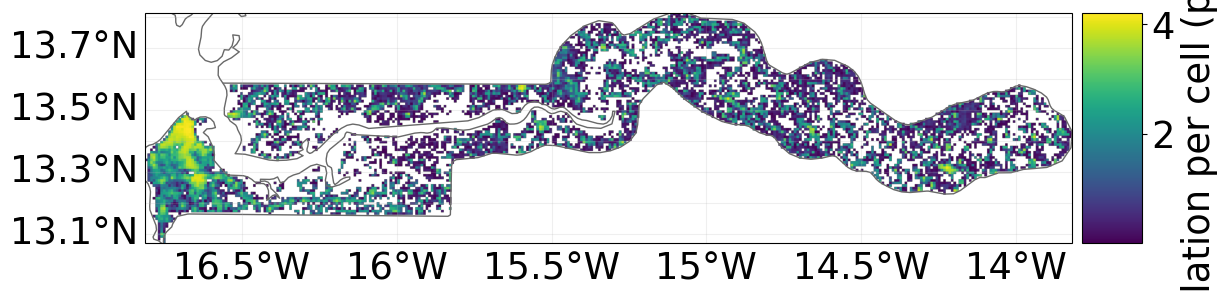

2026-10-10 02:21:18,850 - climada.entity.exposures.base - INFO - Writing /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/hdf5/GMB_ghs_pop_2020_30ss.hdf5
HDF5 written to: /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/hdf5/GMB_ghs_pop_2020_30ss.hdf5


In [15]:
exposure.plot_raster(
    raster_f=lambda values: values,
    label="Population per cell (people)",
    fill=False,
    figsize=(12, 4),
)
plt.show()
plt.close("all")

output_path = OUTPUT_DIR / OUTPUT_FILENAME
exposure.write_hdf5(output_path)
print(f"HDF5 written to: {output_path}")

## Equivalent one-call workflow

Everything above can be done in one call:

INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing GHS-POP tile index: /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHSL_data_4326_shapefile.zip
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Downloading or reusing 1 GHS-POP tile(s) from /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing TIFF: GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reading GHS-POP window: local_path=/Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif window=Window(col_off=381, row_off=633, width=362, height=92)
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Created GHS-POP exposure: year=2020 resolution=30 tiles=['R8_C17'] points=7977 population=2505565.708536059


2026-10-10 03:32:27,865 - climada.util.coordinates - INFO - Raster from resolution 0.008333333299793466 to 0.008333333299793466.


/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
 

<GeoAxes: >

/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr

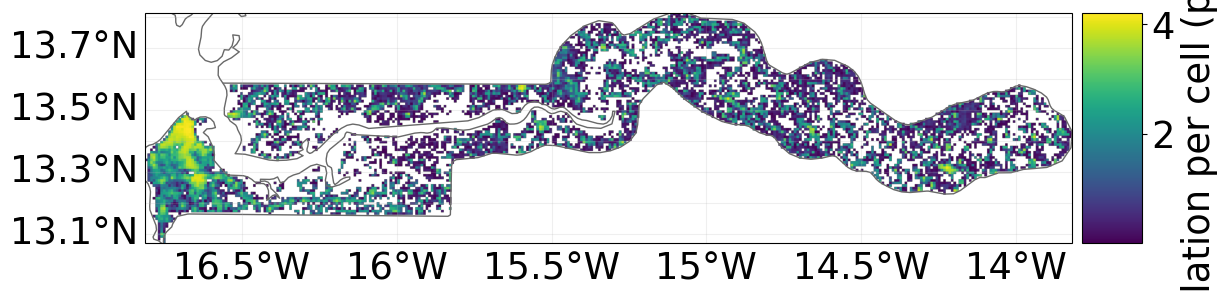

In [17]:
exposure2 = ghs_pop.load_ghs_pop(
    year=YEAR,
    resolution=RESOLUTION,
    country=COUNTRY,
    bounding_box=BOUNDING_BOX,
    download_dir=DOWNLOAD_DIR,
    output_dir=OUTPUT_DIR,
    output_filename=None,
    drop_zeros=DROP_ZEROS,
)
exposure2.plot_raster(
    raster_f=lambda values: values,
    label="Population per cell (people)",
    fill=False,
    figsize=(12, 4),
)

## A bounding box crossing a tile boundary

This separate bounds-only selection spans two adjoining tiles east of Gambia.
The download function retrieves any missing inputs, then the constructor
combines their cropped native-grid cells, without summing duplicated boundary cells. Retain valid zeros here so we
can compare both the population total and all selected cell counts.

INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing GHS-POP tile index: /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHSL_data_4326_shapefile.zip
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Downloading or reusing 2 GHS-POP tile(s) from /Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing TIFF: GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reusing TIFF: GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C18.tif
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reading GHS-POP window: local_path=/Users/chrisfairless/Projects/climada/climada_python/data/exposures/ghs_pop/raw/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R8_C17.tif window=Window(col_off=1080, row_off=611, width=120, height=241)
INFO:climada_toolkit.inputs.exposures.ghs_pop.ghs_pop:Reading GHS-POP window: local_path=/Users/chris

2026-10-10 03:34:07,359 - climada.util.coordinates - INFO - Raster from resolution 0.008333333299793466 to 0.008333333299793466.


/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
 

<GeoAxes: >

/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr

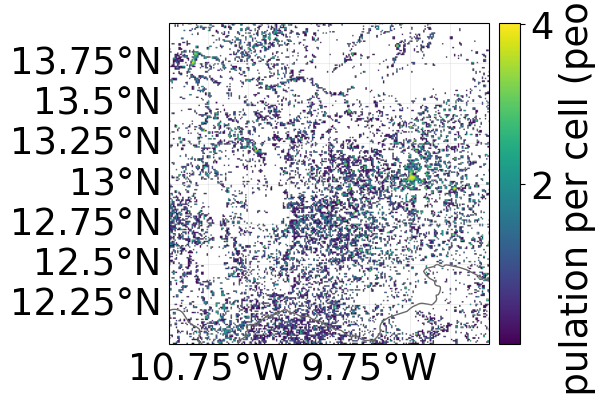

In [19]:
MULTI_TILE_BOUNDS = (-11, 12, -9, 14)
exposure3 = ghs_pop.load_ghs_pop(
    year=YEAR,
    resolution=RESOLUTION,
    country=None,
    bounding_box=MULTI_TILE_BOUNDS,
    download_dir=DOWNLOAD_DIR,
    output_dir=OUTPUT_DIR,
    output_filename=None,
    drop_zeros=DROP_ZEROS,
)
exposure3.plot_raster(
    raster_f=lambda values: values,
    label="Population per cell (people)",
    fill=False,
    figsize=(12, 4),
)

## Source and citation

GHS-POP R2023A is published by the European Commission's Joint Research Centre.
Reuse requires acknowledgement of the source. Consult the
[official dataset record and citation](https://data.jrc.ec.europa.eu/dataset/2ff68a52-5b5b-4a22-8f40-c41da8332cfe),
[product description](https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php)
and [GHSL download page](https://human-settlement.emergency.copernicus.eu/download.php?ds=pop).
Dataset DOI: [10.2905/2FF68A52-5B5B-4A22-8F40-C41DA8332CFE](https://doi.org/10.2905/2FF68A52-5B5B-4A22-8F40-C41DA8332CFE).

Mollweide support and the separate long-range GHS-WUP-POP projection product are
deferred; see `TODO_ghs_pop.md` beside this notebook.

## Optional cleanup

After finishing, use one of these helpers to delete cached files. These calls
are shown here without executing them so the example retains its results.

```python
# Clear out raw TIFF downloads (doesn't touch saved Exposures):
ghs_pop.clear_ghs_pop_downloads(download_dir=DOWNLOAD_DIR)

# Clear out .hdf5 files in the output directory (doesn't touch TIFF downloads):
ghs_pop.clear_ghs_pop_outputs(output_dir=OUTPUT_DIR)

# Clear both plus the cached tile index:
ghs_pop.clear_all_ghs_pop_files(download_dir=DOWNLOAD_DIR, output_dir=OUTPUT_DIR)
```
